In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(0)
torch.manual_seed(0)

channels = ["Fp1", "Fp2", "F3", "O1"]
C = len(channels)

A = np.array([
    [0.0, 0.8, 0.3, 0.05],
    [0.8, 0.0, 0.25, 0.04],
    [0.3, 0.25, 0.0, 0.15],
    [0.05, 0.04, 0.15, 0.0],
])  # diagonal 0: kendine kenar yok, komşuluk yalnızca bu değerlerle

X = torch.tensor([[1.0], [0.9], [0.2], [-0.5]], dtype=torch.float32)  # her node 1 boyutlu özellik
print("Node özellikleri:\n", X.numpy())

Node özellikleri:
 [[ 1. ]
 [ 0.9]
 [ 0.2]
 [-0.5]]


In [ ]:
w_alpha = torch.tensor([1.0, 1.0])  # basitlik için sabit, öğrenilmemiş

def attention_scores(X, A, w_alpha):
    C = X.shape[0]
    Z = torch.zeros(C, C)
    for v in range(C):
        for u in range(C):
            if A[v,u] > 0:   # sadece gerçek komşularda hesapla
                concat = torch.cat([X[v], X[u]])
                Z[v,u] = F.leaky_relu(torch.dot(w_alpha, concat))
            else:
                Z[v,u] = float('-inf')   # komşu değilse softmax'ta 0 ağırlık alsın
    return Z

Z = attention_scores(X, torch.tensor(A), w_alpha)
alpha = F.softmax(Z, dim=1)   # her satır (her node) kendi komşuları üzerinden normalize edilir
print("Ham skorlar (Z):\n", Z.numpy())
print("\nNormalize attention ağırlıkları (alpha):\n", alpha.numpy())

Ham skorlar (Z):
 [[       -inf  1.9         1.2         0.5       ]
 [ 1.9               -inf  1.1         0.39999998]
 [ 1.2         1.1               -inf -0.003     ]
 [ 0.5         0.39999998 -0.003             -inf]]

Normalize attention ağırlıkları (alpha):
 [[0.         0.5736635  0.28487286 0.14146368]
 [0.5979219  0.         0.26866364 0.13341442]
 [0.45348814 0.410333   0.         0.13617884]
 [0.39847764 0.36055747 0.24096493 0.        ]]


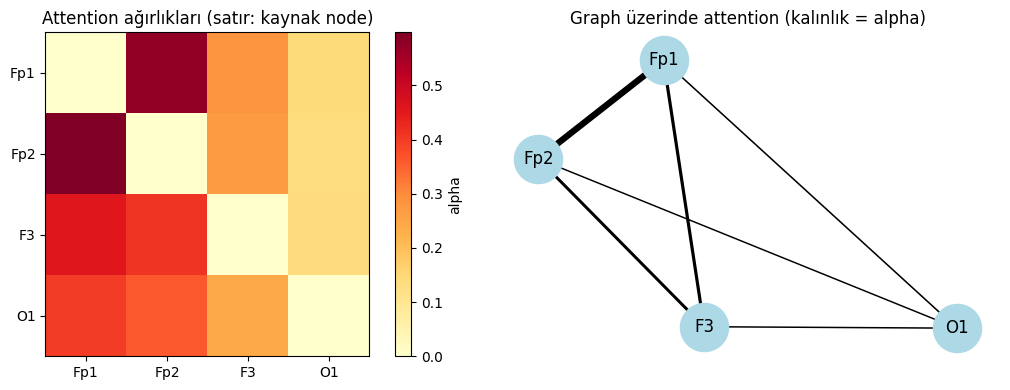

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

im = axes[0].imshow(alpha.detach().numpy(), cmap='YlOrRd', vmin=0)
axes[0].set_xticks(range(C)); axes[0].set_yticks(range(C))
axes[0].set_xticklabels(channels); axes[0].set_yticklabels(channels)
axes[0].set_title("Attention ağırlıkları (satır: kaynak node)")
fig.colorbar(im, ax=axes[0], label="alpha")

G = nx.from_numpy_array(A)
G = nx.relabel_nodes(G, {i: ch for i,ch in enumerate(channels)})
pos = nx.spring_layout(G, seed=1)
edge_weights = [alpha[list(channels).index(u), list(channels).index(v)].item()*8
                for u,v in G.edges()]
nx.draw(G, pos, ax=axes[1], with_labels=True, node_color='lightblue',
        node_size=1200, width=edge_weights)
axes[1].set_title("Graph üzerinde attention (kalınlık = alpha)")

plt.tight_layout()
plt.show()

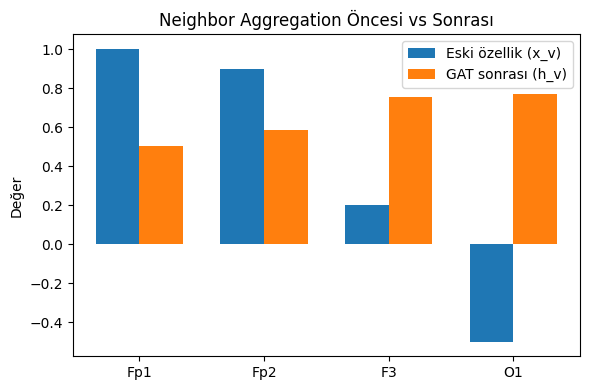

In [ ]:
def neighbor_aggregation(X, alpha, A):
    C = X.shape[0]
    H_new = torch.zeros(C, X.shape[1])
    for v in range(C):
        neighbors = [u for u in range(C) if A[v,u] > 0]
        H_new[v] = sum(alpha[v,u]*X[u] for u in neighbors)
    return H_new

H_new = neighbor_aggregation(X, alpha, torch.tensor(A))

fig, ax = plt.subplots(figsize=(6,4))
x_pos = np.arange(C)
width = 0.35
ax.bar(x_pos - width/2, X.squeeze().numpy(), width, label='Eski özellik (x_v)')
ax.bar(x_pos + width/2, H_new.squeeze().detach().numpy(), width, label='GAT sonrası (h_v)')
ax.set_xticks(x_pos); ax.set_xticklabels(channels)
ax.set_ylabel("Değer")
ax.set_title("Neighbor Aggregation Öncesi vs Sonrası")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def multi_head_gat(X, A, num_heads=3, seed=0):
    torch.manual_seed(seed)
    head_outputs = []
    for h in range(num_heads):
        w_h = torch.randn(2*X.shape[1])  # her head kendi öğrenilebilir vektörüne sahip
        Z_h = attention_scores(X, torch.tensor(A), w_h)
        alpha_h = F.softmax(Z_h, dim=1)
        H_h = neighbor_aggregation(X, alpha_h, torch.tensor(A))
        head_outputs.append(H_h)
    return torch.cat(head_outputs, dim=1)  # concatenate: (C, num_heads * feature_dim)

H_multi = multi_head_gat(X, A, num_heads=3)
print("Tek head çıktı shape:", H_new.shape)
print("3-head çıktı shape:", H_multi.shape)

Tek head çıktı shape: torch.Size([4, 1])
3-head çıktı shape: torch.Size([4, 3])


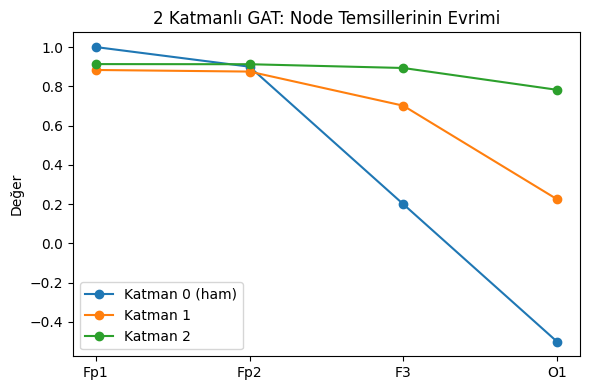

In [ ]:
def gat_layer_with_residual(X, A, w_alpha):
    Z = attention_scores(X, torch.tensor(A), w_alpha)
    alpha = F.softmax(Z, dim=1)
    agg = neighbor_aggregation(X, alpha, torch.tensor(A))
    return torch.tanh(X + agg)   # kendi değeri + komşu agregasyonu

w1 = torch.tensor([0.8, 0.6])
w2 = torch.tensor([0.5, 0.9])

H1 = gat_layer_with_residual(X, A, w1)     # 1. katman
H2 = gat_layer_with_residual(H1, A, w2)    # 2. katman

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(channels, X.squeeze().numpy(), 'o-', label='Katman 0 (ham)')
ax.plot(channels, H1.squeeze().detach().numpy(), 'o-', label='Katman 1')
ax.plot(channels, H2.squeeze().detach().numpy(), 'o-', label='Katman 2')
ax.set_ylabel("Değer")
ax.set_title("2 Katmanlı GAT: Node Temsillerinin Evrimi")
ax.legend()
plt.tight_layout()
plt.show()